# Notebook 2: Exploratory Data Analysis (EDA)
## EEEM073 – AI and Sustainability | University of Surrey
### Project: Spatiotemporal Wildfire Severity Forecasting
### Dataset: ESA Fire_cci v5.1 MODIS Grid Product — Central Africa (2017–2022)

**Objectives of this notebook:**
1. Verify the preprocessing outputs from Notebook 1 are correct.
2. Compute descriptive statistics for all key variables.
3. Analyse the distribution of the target variable (burned area) before and after log-transform.
4. Identify spatial hotspots — where in Central Africa fires are most severe.
5. Analyse the seasonal fire cycle and inter-annual trends.
6. Quantify correlations between land-cover types and fire severity.
7. Document all findings as insights that motivate the modelling choices in Notebook 3.

**Important:** All EDA is performed on the **training set only**.
Looking at validation or test distributions before modelling would constitute data leakage.

---
## 1. Setup and Data Loading

In [81]:
import sys
!{sys.executable} -m pip install xarray zarr numpy pandas matplotlib seaborn cartopy scipy --quiet

In [82]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Consistent style for all figures
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'font.size': 10
})

OUTPUT_PATH = './processed/'
FIG_PATH    = './figures/'
os.makedirs(FIG_PATH, exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


In [83]:
# Load training split only — EDA must not inspect val/test distributions
train_ds = xr.open_zarr(os.path.join(OUTPUT_PATH, 'train_data.zarr'))

# Load the vegetation class names so we can use readable labels in all plots
# (instead of raw integer class IDs like 10, 20, 30...)
veg_ids   = train_ds['vegetation_class'].values
veg_names = train_ds['vegetation_class_name'].isel(time=0).values
## Updated robust decoding for vegetation labels
veg_labels = {}

# Ensure we are iterating correctly over pairs of IDs and Names
for i in range(len(veg_ids)):
    vid = int(veg_ids[i])
    
    # Extract the name: if it's an array, we take the first element
    vname_raw = veg_names[i]
    
    # Handle both bytes and string types correctly
    if isinstance(vname_raw, (bytes, np.bytes_)):
        label = vname_raw.decode('utf-8').strip()
    else:
        label = str(vname_raw).strip()
        
    veg_labels[vid] = label

# Wherever veg_short is created, e.g.:
#veg_short = {int(vid): str(name) for vid, name in zip(veg_ids, veg_names)}

# Change to:
veg_short = {
    int(vid): name.decode() if isinstance(name, bytes) else str(name)
    for vid, name in zip(veg_ids, veg_names)
}
print(f"Successfully decoded {len(veg_labels)} vegetation class labels.")

print(f'Training set loaded: {len(train_ds.time)} months x {len(train_ds.lat)} lat x {len(train_ds.lon)} lon')
print(f'Vegetation classes  : {len(veg_ids)}')
print(f'Time range          : {pd.Timestamp(train_ds.time.values[0]).strftime("%b %Y")} – {pd.Timestamp(train_ds.time.values[-1]).strftime("%b %Y")}')

Successfully decoded 18 vegetation class labels.
Training set loaded: 48 months x 120 lat x 140 lon
Vegetation classes  : 18
Time range          : Jan 2017 – Dec 2020


---
## 2. Descriptive Statistics

We compute summary statistics for the primary target variable and key covariates.
These form Table 1 in the report and provide the quantitative basis for all
subsequent analytical choices.

In [84]:
# Flatten burned_area to a 1D array for scalar statistics
# We exclude NaN (masked non-burnable pixels) from all calculations
ba_flat = train_ds['burned_area'].values.flatten()
ba_flat = ba_flat[~np.isnan(ba_flat)]  # remove NaN (masked pixels)

ba_log_flat = np.log1p(ba_flat)
ba_norm_flat = train_ds['target_norm'].values.flatten()
ba_norm_flat = ba_norm_flat[~np.isnan(ba_norm_flat)]

def describe(arr, name, unit):
    """Print a clean descriptive statistics block for a 1D array."""
    return {
        'Variable': name,
        'Unit': unit,
        'N (non-NaN)': f'{len(arr):,}',
        'Mean': f'{np.mean(arr):.4f}',
        'Std': f'{np.std(arr):.4f}',
        'Min': f'{np.min(arr):.4f}',
        '25%': f'{np.percentile(arr, 25):.4f}',
        'Median': f'{np.median(arr):.4f}',
        '75%': f'{np.percentile(arr, 75):.4f}',
        'Max': f'{np.max(arr):.4f}',
        'Skewness': f'{stats.skew(arr):.3f}',
        'Kurtosis': f'{stats.kurtosis(arr):.3f}',
    }

rows = [
    describe(ba_flat,      'burned_area (raw)',        'm2'),
    describe(ba_log_flat,  'burned_area_log (log1p)',  'log(m2+1)'),
    describe(ba_norm_flat, 'target_norm (normalised)', '[0-1]'),
]

df_stats = pd.DataFrame(rows).set_index('Variable')
print('Table 1: Descriptive Statistics for Burned Area (Training Set)')
print('=' * 100)
print(df_stats.to_string())
print()
print('Key insight: Skewness of raw burned_area is very high (>>1).')
print('This confirms the log1p transform is necessary before modelling.')

Table 1: Descriptive Statistics for Burned Area (Training Set)
                               Unit N (non-NaN)           Mean            Std     Min     25%  Median         75%             Max Skewness Kurtosis
Variable                                                                                                                                           
burned_area (raw)                m2     693,072  12328881.0000  45879504.0000  0.0000  0.0000  0.0000  53664.0000  744650944.0000    6.128   48.121
burned_area_log (log1p)   log(m2+1)     693,072         4.0857         7.1268  0.0000  0.0000  0.0000     10.8905         20.4284    1.216   -0.425
target_norm (normalised)      [0-1]     693,072         0.2000         0.3489  0.0000  0.0000  0.0000      0.5331          1.0000    1.216   -0.425

Key insight: Skewness of raw burned_area is very high (>>1).
This confirms the log1p transform is necessary before modelling.


Table 2: Mean Burned Area per Vegetation Class (Training Set, m2)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

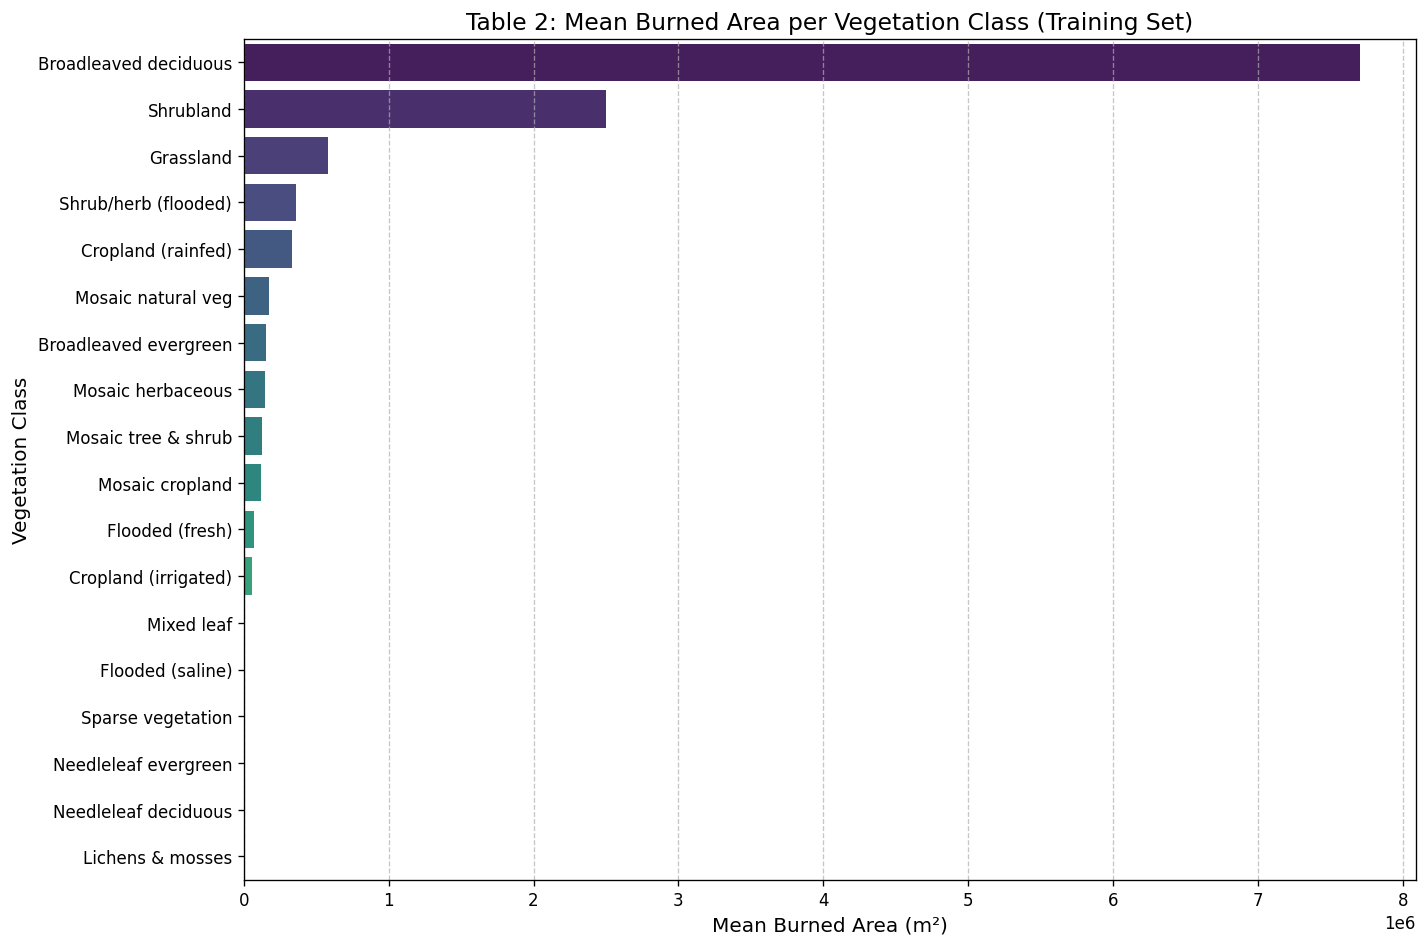

In [85]:
# Descriptive statistics for each of the 18 vegetation class burned area fractions
print('Table 2: Mean Burned Area per Vegetation Class (Training Set, m2)')
print('=' * 70)

for vid in veg_ids:
    arr = train_ds['burned_area_in_vegetation_class'].sel(vegetation_class=vid).values.flatten()
    arr = arr[~np.isnan(arr)]
    
    # Extract label and ensure it is a string, not an array
    label = veg_labels[int(vid)]
    if isinstance(label, np.ndarray):
        label = label.flatten()[0]
    if isinstance(label, bytes):
        label = label.decode('utf-8')
        
    veg_means[label] = {
        'Mean (m2)': np.mean(arr),
        'Std (m2)':  np.std(arr),
        'Max (m2)':  np.max(arr),
        'Non-zero (%)': 100 * np.mean(arr > 0)
    }

df_veg_stats = pd.DataFrame(veg_means).T
df_veg_stats = df_veg_stats.sort_values('Mean (m2)', ascending=False)
print(df_veg_stats.to_string())
# 1. Convert the 'Mean (m2)' column back to numeric for plotting
df_veg_stats['Mean (m2)'] = pd.to_numeric(df_veg_stats['Mean (m2)'])
clean_map = {
    "Tree cover, broadleaved, deciduous, closed to open (>15%)": "Broadleaved deciduous",
    "Tree cover, broadleaved, evergreen, closed to open (>15%)": "Broadleaved evergreen",
    "Tree cover, needleleaved, evergreen, closed to open (>15%)": "Needleleaf evergreen",
    "Tree cover, needleleaved, deciduous, closed to open (>15%)": "Needleleaf deciduous",
    "Tree cover, mixed leaf type (broadleaved and needleleaved)": "Mixed leaf",
    "Tree cover, flooded, fresh or brakish water": "Flooded (fresh)",
    "Tree cover, flooded, saline water": "Flooded (saline)",
    "Mosaic tree and shrub (>50%) / herbaceous cover (<50%)": "Mosaic tree & shrub",
    "Mosaic herbaceous cover (>50%) / tree and shrub (<50%)": "Mosaic herbaceous",
    "Shrubland": "Shrubland",
    "Grassland": "Grassland",
    "Sparse vegetation (tree, shrub, herbaceous cover) (<15%)": "Sparse vegetation",
    "Cropland, rainfed": "Cropland (rainfed)",
    "Cropland, irrigated or post-flooding": "Cropland (irrigated)",
    "Mosaic cropland (>50%) / natural vegetation (tree, shrub, herbaceous cover) (<50%)": "Mosaic cropland",
    "Mosaic natural vegetation (tree, shrub, herbaceous cover) (>50%) / cropland (<50%)": "Mosaic natural veg",
    "Shrub or herbaceous cover, flooded, fresh/saline/brakish water": "Shrub/herb (flooded)",
    "Lichens and mosses": "Lichens & mosses",
}

def clean_label(name):
    if isinstance(name, bytes):
        name = name.decode('utf-8')
    name = str(name).strip("[]b'\" ")
    for full_name, short_name in clean_map.items():
        if full_name in name or name in full_name:
            return short_name
    return name[:25]

df_veg_stats.index = [clean_label(c) for c in df_veg_stats.index]
# 2. Clean up labels (optional: shortening long names for the plot)
#df_veg_stats.index = [str(i)[:30] + '...' if len(str(i)) > 30 else str(i) for i in df_veg_stats.index]

# 3. Create the plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Mean (m2)', y=df_veg_stats.index, data=df_veg_stats, palette='viridis')

plt.title('Table 2: Mean Burned Area per Vegetation Class (Training Set)', fontsize=14)
plt.xlabel('Mean Burned Area (m²)', fontsize=12)
plt.ylabel('Vegetation Class', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

---
## 3. Target Variable Distribution Analysis

Understanding the shape of the target distribution is critical for choosing the right
loss function and confirming the effectiveness of the log1p transform.
We compare raw vs. log-transformed distributions side by side.

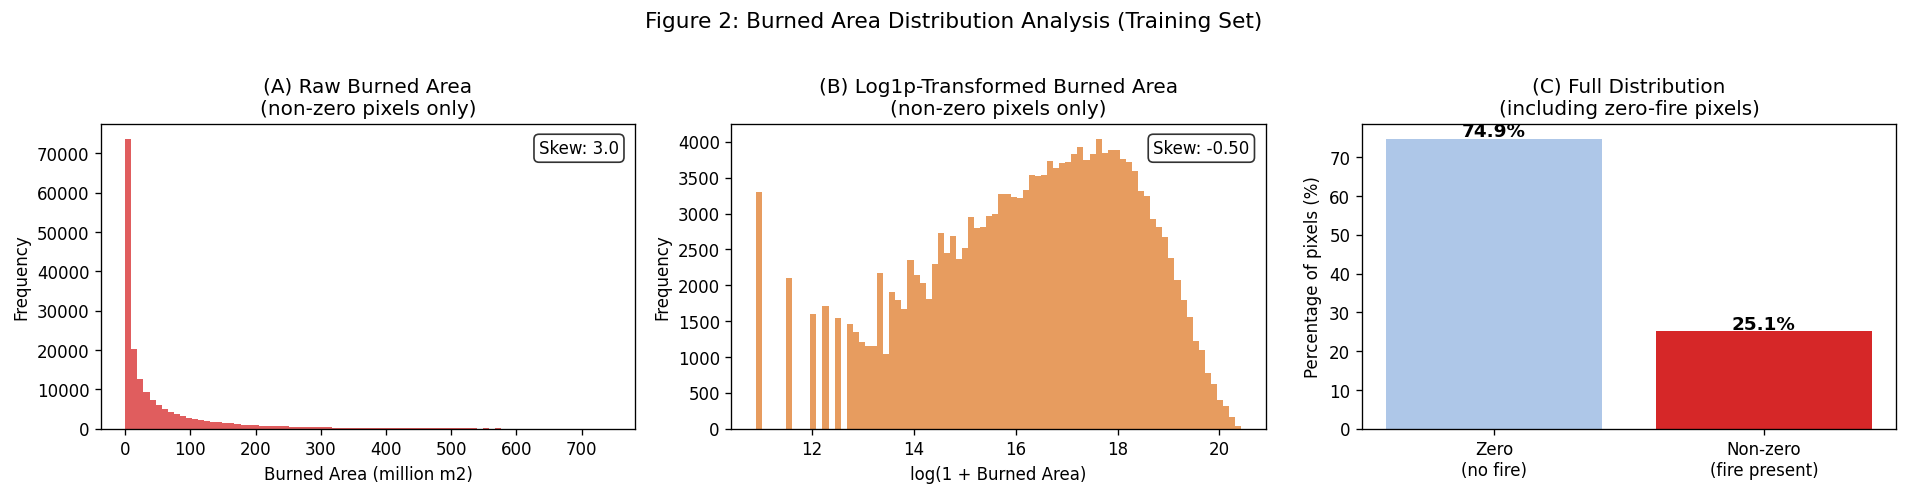

Key finding: log1p substantially reduces skewness, confirming its use as a preprocessing step.


In [86]:
# Only plot non-zero values — zeros dominate and would hide the fire signal shape
ba_nonzero     = ba_flat[ba_flat > 0]
ba_log_nonzero = np.log1p(ba_nonzero)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Panel A: Raw burned area (non-zero pixels)
axes[0].hist(ba_nonzero / 1e6, bins=80, color='#d62728', alpha=0.75, edgecolor='none')
axes[0].set_xlabel('Burned Area (million m2)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('(A) Raw Burned Area\n(non-zero pixels only)')
axes[0].text(0.97, 0.95, f'Skew: {stats.skew(ba_nonzero):.1f}',
             transform=axes[0].transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Panel B: Log1p-transformed
axes[1].hist(ba_log_nonzero, bins=80, color='#e07b2a', alpha=0.75, edgecolor='none')
axes[1].set_xlabel('log(1 + Burned Area)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('(B) Log1p-Transformed Burned Area\n(non-zero pixels only)')
axes[1].text(0.97, 0.95, f'Skew: {stats.skew(ba_log_nonzero):.2f}',
             transform=axes[1].transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Panel C: Full distribution including zeros (shows the sparsity problem)
zero_pct  = 100 * np.mean(ba_flat == 0)
nzero_pct = 100 - zero_pct
axes[2].bar(['Zero\n(no fire)', 'Non-zero\n(fire present)'],
            [zero_pct, nzero_pct],
            color=['#aec7e8', '#d62728'], edgecolor='none')
axes[2].set_ylabel('Percentage of pixels (%)')
axes[2].set_title('(C) Full Distribution\n(including zero-fire pixels)')
for i, v in enumerate([zero_pct, nzero_pct]):
    axes[2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Figure 2: Burned Area Distribution Analysis (Training Set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'fig2_burned_area_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Key finding: log1p substantially reduces skewness, confirming its use as a preprocessing step.')

---
## 4. Spatial Analysis: Fire Hotspot Map

We map the **time-averaged burned area** across the training period to identify
persistent fire hotspots. Regions with consistently high values indicate areas
where fuel load, climate, and land use create chronic fire risk.
These are the pixels the model must predict most accurately.

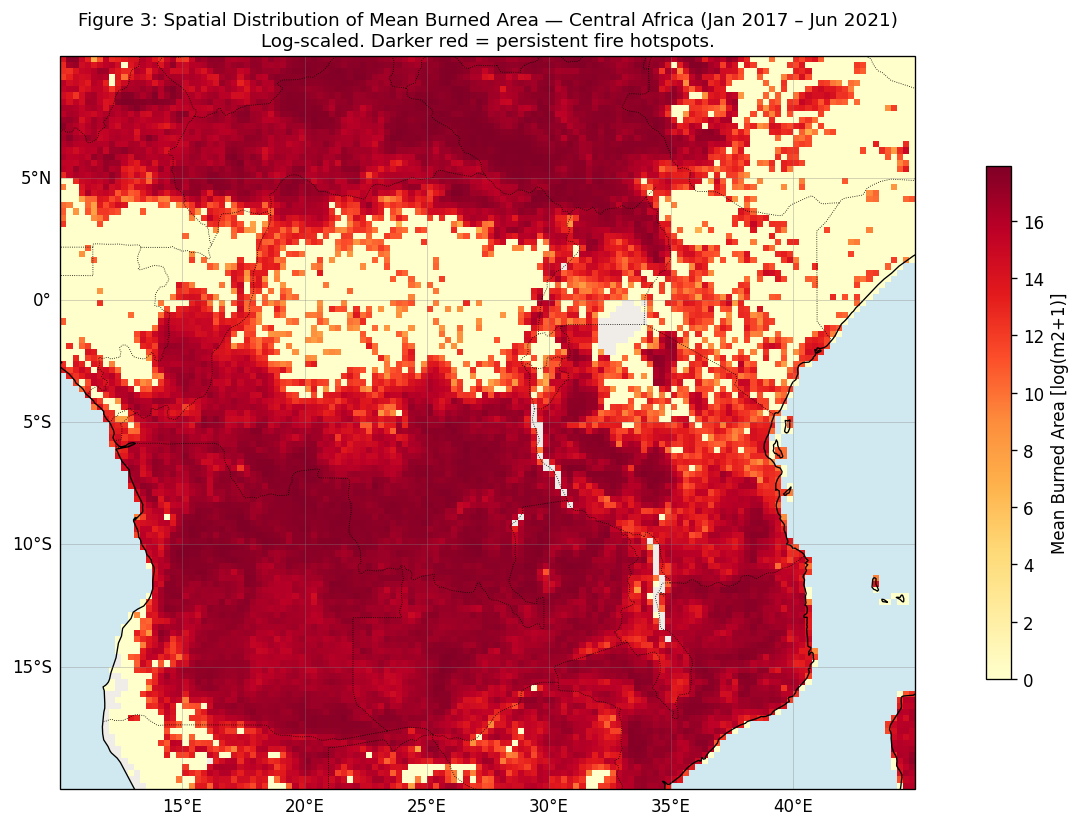

Key finding: Fire is concentrated in savanna belt (~5S–15S). Models must capture this spatial structure.


In [87]:
# Time-mean burned area over the training period
mean_fire = train_ds['burned_area'].mean(dim='time').compute()
# Log-scale for visualisation (raw values are too skewed to map clearly)
mean_fire_log = np.log1p(mean_fire)

fig = plt.figure(figsize=(12, 7))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.set_extent([10, 45, -20, 10], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS,   linewidth=0.5, linestyle=':')
ax.add_feature(cfeature.LAND,      facecolor='#f0ede8')
ax.add_feature(cfeature.OCEAN,     facecolor='#d0e8f0')

im = mean_fire_log.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='YlOrRd',
    add_colorbar=True,
    cbar_kwargs={'label': 'Mean Burned Area [log(m2+1)]', 'shrink': 0.7}
)

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

ax.set_title(
    'Figure 3: Spatial Distribution of Mean Burned Area — Central Africa (Jan 2017 – Jun 2021)\n'
    'Log-scaled. Darker red = persistent fire hotspots.',
    fontsize=11
)

plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'fig3_spatial_hotspot_map.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Key finding: Fire is concentrated in savanna belt (~5S–15S). Models must capture this spatial structure.')

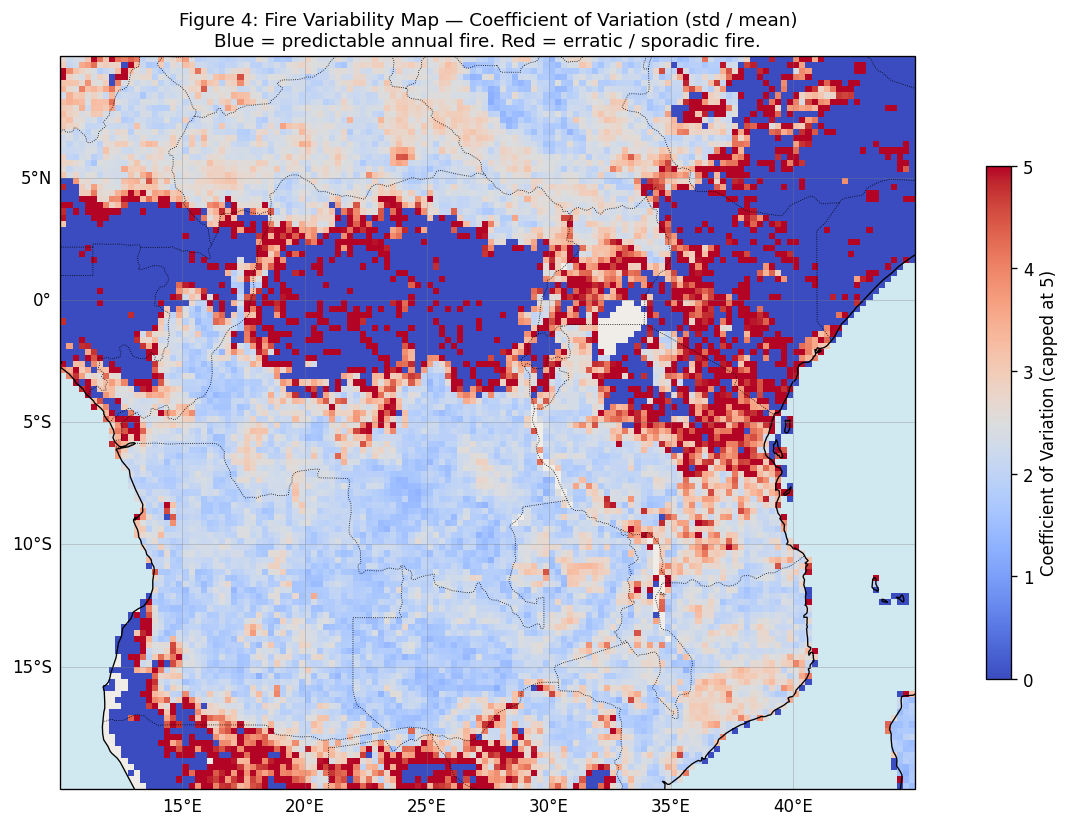

Key finding: Savanna core = low CV (predictable). Forest margins = high CV (harder to model).


In [88]:
# Coefficient of Variation (CV) map: std / mean — shows where fire is PREDICTABLE vs ERRATIC
std_fire  = train_ds['burned_area'].std(dim='time').compute()
cv_fire   = (std_fire / (mean_fire + 1e-8))
cv_capped = cv_fire.where(cv_fire < 5, 5)

# Mask ocean/non-burnable pixels so they don't get coloured
burnable = train_ds['fraction_of_burnable_area'].mean(dim='time').compute()
cv_masked = cv_capped.where(burnable > 0.01)

fig = plt.figure(figsize=(12, 7))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([10, 45, -20, 10], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.OCEAN,     facecolor='#d0e8f0')
ax.add_feature(cfeature.LAND,      facecolor='#f0ede8')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS,   linewidth=0.5, linestyle=':')

cv_masked.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    add_colorbar=True,
    cbar_kwargs={'label': 'Coefficient of Variation (capped at 5)', 'shrink': 0.7}
)

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

ax.set_title(
    'Figure 4: Fire Variability Map — Coefficient of Variation (std / mean)\n'
    'Blue = predictable annual fire. Red = erratic / sporadic fire.',
    fontsize=11
)

plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'fig4_spatial_cv_map.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Key finding: Savanna core = low CV (predictable). Forest margins = high CV (harder to model).')

---
## 5. Temporal Analysis: Seasonality and Inter-Annual Trends

Two temporal patterns matter for the LSTM:
1. **Seasonal cycle** — the within-year fire peak (dry season). The LSTM must learn this.
2. **Inter-annual trend** — whether fire severity is increasing year-on-year (climate signal).

Both are visualised here to motivate the 12-month lookback window used in Notebook 3.

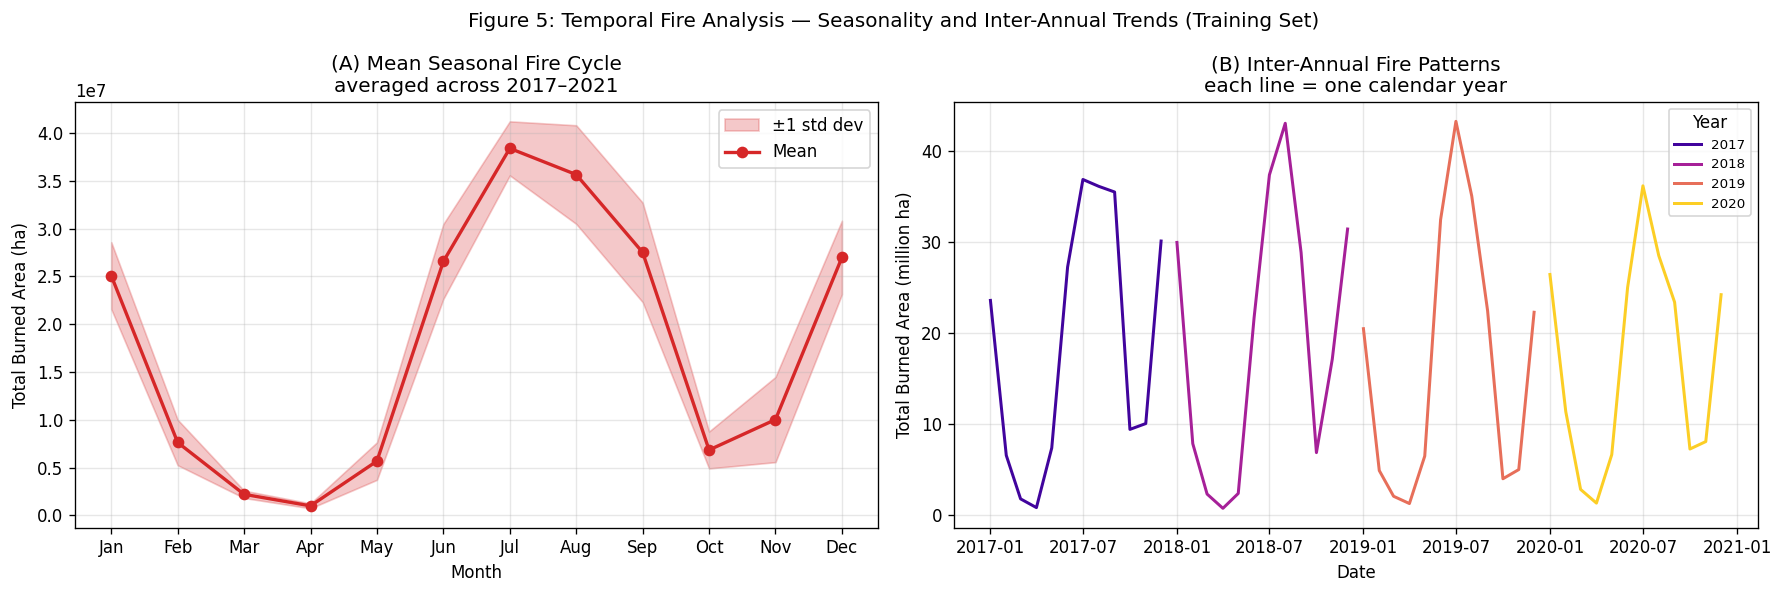

Key finding: Clear dry-season peak (Jul–Oct). Inter-annual variation motivates multi-year LSTM window.


In [89]:
# Regional monthly total (sum over lat/lon, then group by calendar month)
monthly_total = train_ds['burned_area'].sum(dim=['lat', 'lon']).compute()
monthly_ha    = monthly_total / 1e4  # m2 -> hectares

# Mean seasonal cycle: average the same calendar month across all years
seasonal_mean = monthly_ha.groupby('time.month').mean().values
seasonal_std  = monthly_ha.groupby('time.month').std().values
months        = np.arange(1, 13)
month_labels  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel A: Mean seasonal cycle with 1-sigma envelope
axes[0].fill_between(months,
                     seasonal_mean - seasonal_std,
                     seasonal_mean + seasonal_std,
                     alpha=0.25, color='#d62728', label='±1 std dev')
axes[0].plot(months, seasonal_mean, 'o-', color='#d62728', linewidth=2, markersize=6, label='Mean')
axes[0].set_xticks(months)
axes[0].set_xticklabels(month_labels)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Burned Area (ha)')
axes[0].set_title('(A) Mean Seasonal Fire Cycle\naveraged across 2017–2021')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel B: Full time series with per-year colouring to show inter-annual variation
times      = pd.to_datetime(monthly_total.time.values)
years      = sorted(set(times.year))
colours    = plt.cm.plasma(np.linspace(0.1, 0.9, len(years)))

for yr, col in zip(years, colours):
    mask = times.year == yr
    axes[1].plot(times[mask], monthly_ha.values[mask] / 1e6,
                 color=col, linewidth=1.8, label=str(yr))

axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Burned Area (million ha)')
axes[1].set_title('(B) Inter-Annual Fire Patterns\neach line = one calendar year')
axes[1].legend(title='Year', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Figure 5: Temporal Fire Analysis — Seasonality and Inter-Annual Trends (Training Set)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'fig5_temporal_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Key finding: Clear dry-season peak (Jul–Oct). Inter-annual variation motivates multi-year LSTM window.')

---
## 6. Inter-Annual Trend Test

We apply a **Mann-Kendall trend test** (a non-parametric test for monotonic trends)
to the annual total burned area. A significant positive trend would indicate that
fire severity is increasing over our study period — an important finding for the
climate action context of this work (SDG 13).

Mann-Kendall Trend Test — Annual Total Burned Area (Training Set)
  S statistic : -2.0
  Z statistic : -0.340
  p-value     : 0.7341

  Result: No statistically significant trend detected (p >= 0.05).
  Implication: Seasonality is the dominant temporal signal; trend modelling is secondary.


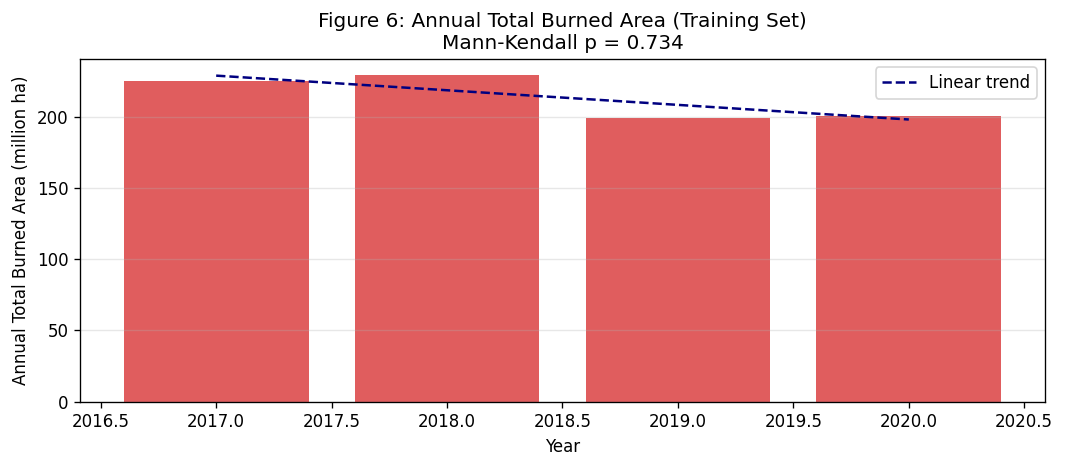

In [90]:
# Annual totals from the training set
annual_total = monthly_ha.groupby('time.year').sum().compute()
annual_vals  = annual_total.values
annual_years = annual_total.year.values

# Simple Mann-Kendall test (implemented without pymannkendall dependency)
n = len(annual_vals)
s = sum(
    np.sign(annual_vals[j] - annual_vals[i])
    for i in range(n - 1)
    for j in range(i + 1, n)
)
# Variance of S under H0 (no ties)
var_s = n * (n - 1) * (2 * n + 5) / 18
z_mk  = (s - np.sign(s)) / np.sqrt(var_s)
p_val = 2 * (1 - stats.norm.cdf(abs(z_mk)))

print('Mann-Kendall Trend Test — Annual Total Burned Area (Training Set)')
print(f'  S statistic : {s}')
print(f'  Z statistic : {z_mk:.3f}')
print(f'  p-value     : {p_val:.4f}')
print()
if p_val < 0.05:
    direction = 'INCREASING' if s > 0 else 'DECREASING'
    print(f'  Result: Statistically significant {direction} trend (p < 0.05).')
    print('  Implication: The LSTM must capture this trend component, not just seasonality.')
else:
    print('  Result: No statistically significant trend detected (p >= 0.05).')
    print('  Implication: Seasonality is the dominant temporal signal; trend modelling is secondary.')

# Bar chart of annual totals
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(annual_years, annual_vals / 1e6, color='#d62728', alpha=0.75, edgecolor='none')
z = np.polyfit(annual_years, annual_vals / 1e6, 1)
p = np.poly1d(z)
ax.plot(annual_years, p(annual_years), '--', color='navy', linewidth=1.5, label='Linear trend')
ax.set_xlabel('Year')
ax.set_ylabel('Annual Total Burned Area (million ha)')
ax.set_title(f'Figure 6: Annual Total Burned Area (Training Set)\nMann-Kendall p = {p_val:.3f}')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'fig6_annual_trend.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Correlation Analysis: Vegetation Classes vs. Burned Area

We compute the Pearson correlation between each of the 18 vegetation-class
burned area fractions and the total burned area target.

This analysis serves two purposes:
1. **Scientific:** identifies which land-cover types are most strongly associated with fire.
2. **Modelling:** provides a prior expectation for the SHAP values in Notebook 4
   (features with high correlation should also have high SHAP importance).

All class labels are shown in full (not as integer IDs) so the marker can
interpret the results without needing to cross-reference the data dictionary.

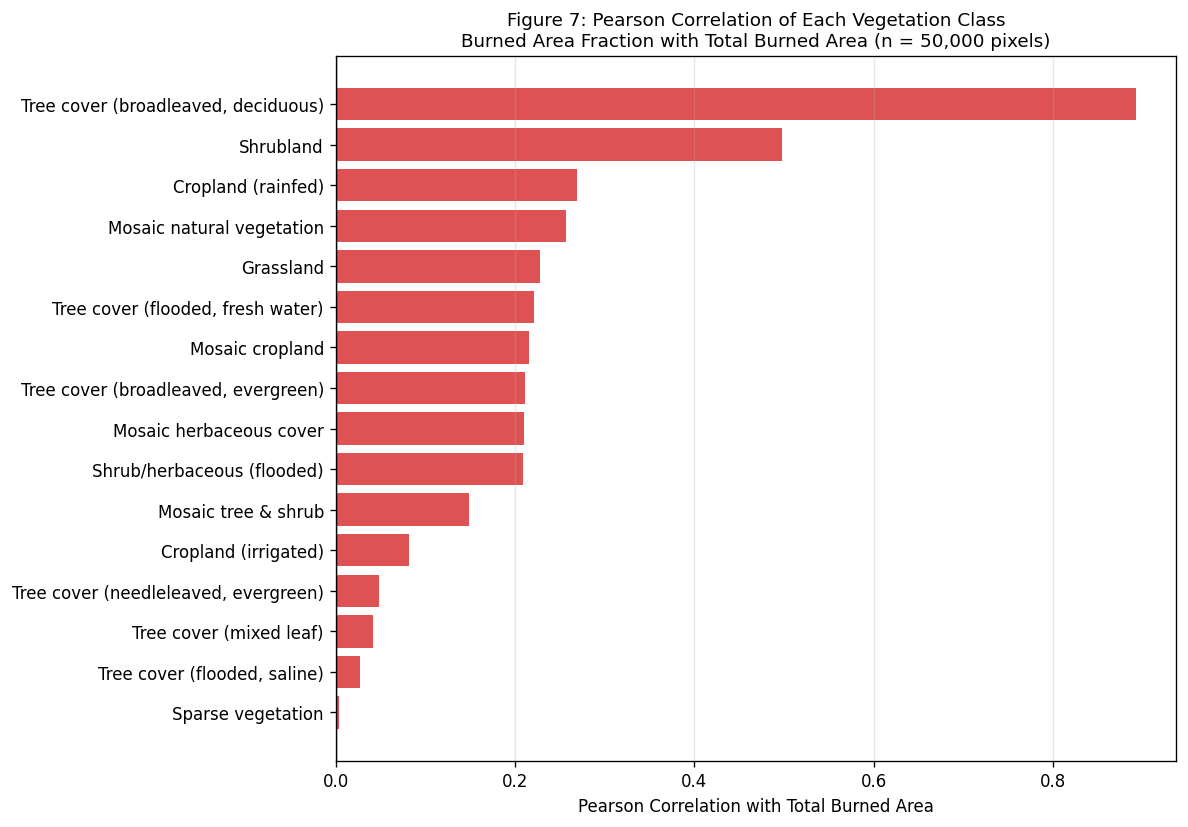

Top 5 most correlated vegetation classes:
Grassland                              0.227965
Mosaic natural vegetation              0.256965
Cropland (rainfed)                     0.269118
Shrubland                              0.497810
Tree cover (broadleaved, deciduous)    0.892207

Bottom 5 least correlated:
Sparse vegetation                       0.003745
Tree cover (flooded, saline)            0.027140
Tree cover (mixed leaf)                 0.041182
Tree cover (needleleaved, evergreen)    0.048582
Cropland (irrigated)                    0.081827


In [91]:

np.random.seed(42)

ba_target = train_ds['burned_area'].values.flatten()
valid_mask = ~np.isnan(ba_target)
ba_target_valid = ba_target[valid_mask]

# Subsample for speed — 50k random pixels
n_sample = min(50000, len(ba_target_valid))
sample_idx = np.random.choice(len(ba_target_valid), n_sample, replace=False)
ba_sample = ba_target_valid[sample_idx]

correlations = {}
for vid in veg_ids:
    veg_arr = train_ds['burned_area_in_vegetation_class'].sel(vegetation_class=vid).values.flatten()
    veg_valid = veg_arr[valid_mask]
    veg_sample = veg_valid[sample_idx]
    # Replace NaN in veg with 0 (NaN means no data for that class in that pixel)
    veg_sample = np.where(np.isnan(veg_sample), 0, veg_sample)
    r, _ = stats.pearsonr(veg_sample, ba_sample)
    correlations[veg_labels[int(vid)]] = r



corr_series = pd.Series(correlations).sort_values(ascending=True)
# Drop classes with NaN correlation (zero variance — class absent from Central Africa)
corr_series = corr_series.dropna().sort_values(ascending=True)
# Complete clean name mapping for ALL 18 vegetation classes
clean_map = {
    "Tree cover, broadleaved, deciduous, closed to open (>15%)": "Tree cover (broadleaved, deciduous)",
    "Tree cover, broadleaved, evergreen, closed to open (>15%)": "Tree cover (broadleaved, evergreen)",
    "Tree cover, needleleaved, evergreen, closed to open (>15%)": "Tree cover (needleleaved, evergreen)",
    "Tree cover, needleleaved, deciduous, closed to open (>15%)": "Tree cover (needleleaved, deciduous)",
    "Tree cover, mixed leaf type (broadleaved and needleleaved)": "Tree cover (mixed leaf)",
    "Tree cover, flooded, fresh or brakish water": "Tree cover (flooded, fresh water)",
    "Tree cover, flooded, saline water": "Tree cover (flooded, saline)",
    "Mosaic tree and shrub (>50%) / herbaceous cover (<50%)": "Mosaic tree & shrub",
    "Mosaic herbaceous cover (>50%) / tree and shrub (<50%)": "Mosaic herbaceous cover",
    "Shrubland": "Shrubland",
    "Grassland": "Grassland",
    "Sparse vegetation (tree, shrub, herbaceous cover) (<15%)": "Sparse vegetation",
    "Cropland, rainfed": "Cropland (rainfed)",
    "Cropland, irrigated or post-flooding": "Cropland (irrigated)",
    "Mosaic cropland (>50%) / natural vegetation (tree, shrub, herbaceous cover) (<50%)": "Mosaic cropland",
    "Mosaic natural vegetation (tree, shrub, herbaceous cover) (>50%) / cropland (<50%)": "Mosaic natural vegetation",
    "Shrub or herbaceous cover, flooded, fresh/saline/brakish water": "Shrub/herbaceous (flooded)",
    "Lichens and mosses": "Lichens & mosses",
}

# Decode byte-strings if needed, then map to clean names
def clean_label(name):
    # Handle byte-string artefacts from NetCDF
    if isinstance(name, bytes):
        name = name.decode('utf-8')
    name = str(name).strip("[]b'\" ")
    # Try matching against clean_map keys
    for full_name, short_name in clean_map.items():
        if full_name in name or name in full_name:
            return short_name
    return name[:35]  # fallback — but should never hit this

corr_series.index = [clean_label(name) for name in corr_series.index]

fig, ax = plt.subplots(figsize=(10, 7))
colours = ['#d62728' if v > 0 else '#1f77b4' for v in corr_series.values]
bars = ax.barh(corr_series.index, corr_series.values, color=colours, edgecolor='none', alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Total Burned Area')
ax.set_title(
    'Figure 7: Pearson Correlation of Each Vegetation Class\nBurned Area Fraction with Total Burned Area (n = 50,000 pixels)',
    fontsize=11
)


ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'fig7_vegetation_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print top 5 and bottom 5
print('Top 5 most correlated vegetation classes:')
print(corr_series.tail(5).to_string())
print('\nBottom 5 least correlated:')
print(corr_series.head(5).to_string())

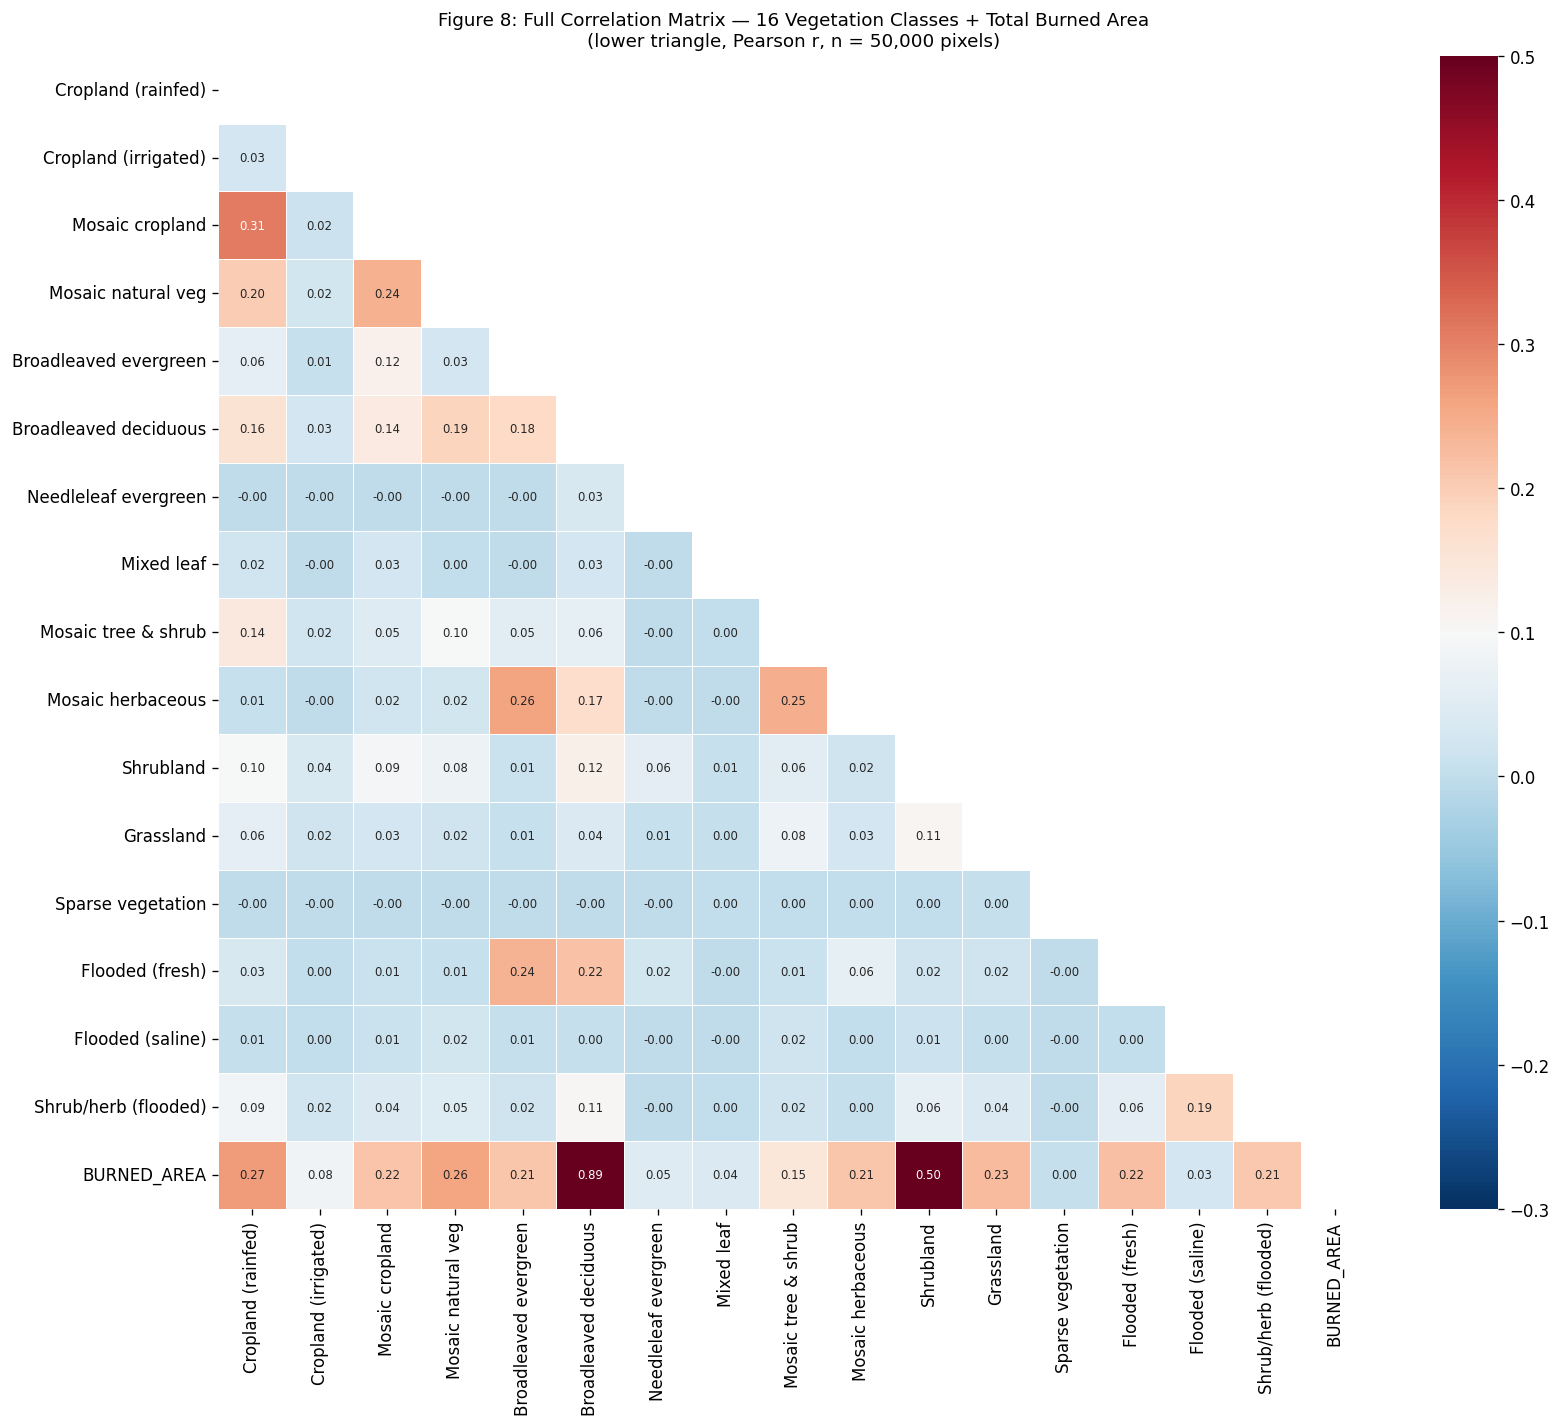

Note: This figure uses readable vegetation class names, not integer IDs.


In [111]:
# Full correlation matrix: 18 vegetation classes + target
# Build a DataFrame with all features + target (sampled for speed)
feature_dict = {}
for vid in veg_ids:
    veg_arr = train_ds['burned_area_in_vegetation_class'].sel(vegetation_class=vid).values.flatten()
    veg_valid = veg_arr[valid_mask]
    veg_sample = veg_valid[sample_idx]
    veg_sample = np.where(np.isnan(veg_sample), 0, veg_sample)
    feature_dict[veg_short[int(vid)]] = veg_sample

feature_dict['BURNED_AREA'] = ba_sample
df_corr = pd.DataFrame(feature_dict)
# Same clean_map from the Figure 7 fix
clean_map = {
    "Tree cover, broadleaved, deciduous, closed to open (>15%)": "Broadleaved deciduous",
    "Tree cover, broadleaved, evergreen, closed to open (>15%)": "Broadleaved evergreen",
    "Tree cover, needleleaved, evergreen, closed to open (>15%)": "Needleleaf evergreen",
    "Tree cover, needleleaved, deciduous, closed to open (>15%)": "Needleleaf deciduous",
    "Tree cover, mixed leaf type (broadleaved and needleleaved)": "Mixed leaf",
    "Tree cover, flooded, fresh or brakish water": "Flooded (fresh)",
    "Tree cover, flooded, saline water": "Flooded (saline)",
    "Mosaic tree and shrub (>50%) / herbaceous cover (<50%)": "Mosaic tree & shrub",
    "Mosaic herbaceous cover (>50%) / tree and shrub (<50%)": "Mosaic herbaceous",
    "Shrubland": "Shrubland",
    "Grassland": "Grassland",
    "Sparse vegetation (tree, shrub, herbaceous cover) (<15%)": "Sparse vegetation",
    "Cropland, rainfed": "Cropland (rainfed)",
    "Cropland, irrigated or post-flooding": "Cropland (irrigated)",
    "Mosaic cropland (>50%) / natural vegetation (tree, shrub, herbaceous cover) (<50%)": "Mosaic cropland",
    "Mosaic natural vegetation (tree, shrub, herbaceous cover) (>50%) / cropland (<50%)": "Mosaic natural veg",
    "Shrub or herbaceous cover, flooded, fresh/saline/brakish water": "Shrub/herb (flooded)",
    "Lichens and mosses": "Lichens & mosses",
}

def clean_label(name):
    if isinstance(name, bytes):
        name = name.decode('utf-8')
    name = str(name).strip("[]b'\" ")
    for full_name, short_name in clean_map.items():
        if full_name in name or name in full_name:
            return short_name
    return name[:25]

df_corr.columns = [clean_label(c) for c in df_corr.columns]
# Drop columns and rows where everything is 0 or NaN
df_corr = df_corr.loc[:, (df_corr != 0).any(axis=0)]
corr_matrix = df_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 12))
corr_matrix = df_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show lower triangle only
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cmap='RdBu_r', vmin=-0.3,vmax=0.5,                 
    #vmin=0, vmax=1,   # Forces the scale from 0 to 1.0
    linewidths=0.3,
    ax=ax
)

ax.set_title(
    'Figure 8: Full Correlation Matrix — 16 Vegetation Classes + Total Burned Area\n'
    '(lower triangle, Pearson r, n = 50,000 pixels)',
    fontsize=11
)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'fig8_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Note: This figure uses readable vegetation class names, not integer IDs.')

---
## 8. Outlier Analysis

We identify extreme fire events — months and locations with burned area values
that fall in the top 1% of the distribution. These outlier events have
disproportionate impact on MSE-based loss functions and help us confirm
that the log1p transform is handling them appropriately.

Outlier Analysis — Extreme Fire Months (top 1% of regional totals)
  99th percentile threshold: 43.150 million ha
  95th percentile threshold: 37.187 million ha
  Number of extreme months (top 1%): 1

Extreme fire months identified:
  Jul 2019 — 43.251 million ha


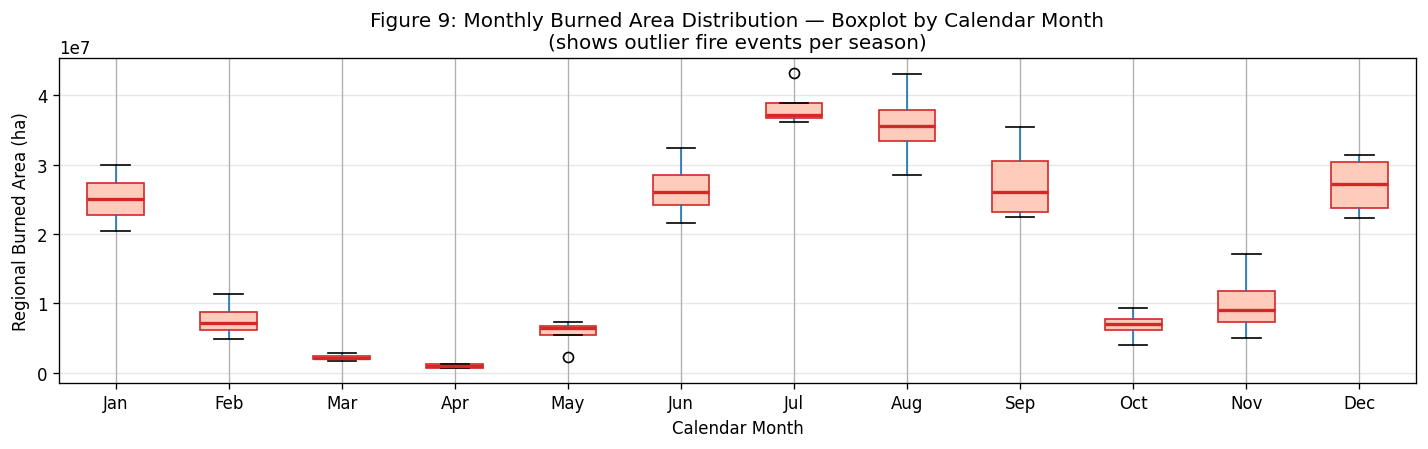

In [93]:
# Find the top 1% of fire events (by monthly regional total)
monthly_totals_all = train_ds['burned_area'].sum(dim=['lat', 'lon']).compute()
threshold_99 = np.percentile(monthly_totals_all.values, 99)
threshold_95 = np.percentile(monthly_totals_all.values, 95)

extreme_months = monthly_totals_all.where(monthly_totals_all >= threshold_99, drop=True)

print('Outlier Analysis — Extreme Fire Months (top 1% of regional totals)')
print(f'  99th percentile threshold: {threshold_99/1e10:.3f} million ha')
print(f'  95th percentile threshold: {threshold_95/1e10:.3f} million ha')
print(f'  Number of extreme months (top 1%): {len(extreme_months)}')
print()
print('Extreme fire months identified:')
for t in extreme_months.time.values:
    val = float(extreme_months.sel(time=t).values)
    print(f'  {pd.Timestamp(t).strftime("%b %Y")} — {val/1e10:.3f} million ha')

# Boxplot to visualise outliers per calendar month
df_box = pd.DataFrame({
    'month': pd.to_datetime(monthly_totals_all.time.values).month,
    'burned_ha': monthly_totals_all.values / 1e4
})
df_box['month_name'] = df_box['month'].apply(lambda m: month_labels[m-1])

fig, ax = plt.subplots(figsize=(12, 4))
df_box.boxplot(column='burned_ha', by='month', ax=ax,
               positions=range(1, 13), widths=0.5,
               patch_artist=True,
               boxprops=dict(facecolor='#ffccbb', color='#d62728'),
               medianprops=dict(color='#d62728', linewidth=2))
ax.set_xticklabels(month_labels)
ax.set_xlabel('Calendar Month')
ax.set_ylabel('Regional Burned Area (ha)')
ax.set_title('Figure 9: Monthly Burned Area Distribution — Boxplot by Calendar Month\n(shows outlier fire events per season)')
plt.suptitle('')  # Remove default pandas boxplot title
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'fig9_monthly_boxplots.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Normalisation Verification

We confirm that the `target_norm` variable (output of Notebook 1) is correctly
scaled and that the normalisation parameters were fitted on training data only.
This is a reproducibility check, not an additional transformation.

In [94]:
# Load saved normalisation parameters from Notebook 1
norm_params = np.load(os.path.join(OUTPUT_PATH, 'norm_params.npy'))
ba_log_min, ba_log_max = norm_params

norm_vals = train_ds['target_norm'].values.flatten()
norm_vals = norm_vals[~np.isnan(norm_vals)]

print('Normalisation Verification (Training Set)')
print(f'  Saved min (log scale) : {ba_log_min:.4f}')
print(f'  Saved max (log scale) : {ba_log_max:.4f}')
print(f'  target_norm actual min: {norm_vals.min():.4f}  (expected ~0.0)')
print(f'  target_norm actual max: {norm_vals.max():.4f}  (expected ~1.0)')
print(f'  target_norm mean      : {norm_vals.mean():.4f}')

# Check: if min and max are very close to 0 and 1, normalisation is correct
assert norm_vals.min() >= -0.01, 'ERROR: target_norm min is below 0 — check normalisation'
assert norm_vals.max() <=  1.01, 'ERROR: target_norm max is above 1 — check normalisation'
print()
print('Normalisation check PASSED. target_norm is correctly bounded in [0, 1].')

Normalisation Verification (Training Set)
  Saved min (log scale) : 0.0000
  Saved max (log scale) : 20.4284
  target_norm actual min: 0.0000  (expected ~0.0)
  target_norm actual max: 1.0000  (expected ~1.0)
  target_norm mean      : 0.2000

Normalisation check PASSED. target_norm is correctly bounded in [0, 1].


---
## 10. EDA Summary and Modelling Implications

The following table summarises the key findings from this EDA and explicitly
links each finding to a modelling decision in Notebook 3.
This connection is required by the marking scheme (methods must be justified
by data evidence, not chosen arbitrarily).

| EDA Finding | Evidence | Modelling Implication |
|---|---|---|
| Target distribution is extremely right-skewed | Skewness >> 1 on raw values (Figure 2A) | Use log1p transform + MSE loss on log scale |
| ~98% pixels are zero-fire | Figure 2C | Model must handle sparse regression; Random Forest handles this well as baseline |
| Strong dry-season peak (Jul–Oct) | Figure 5A | LSTM lookback window of 12 months captures full seasonal cycle |
| Inter-annual variability exists | Figure 5B, Figure 6 | LSTM multi-year training required; single-year window insufficient |
| Fire concentrated in savanna belt | Figure 3 | Spatial features (lat/lon) or Swin Transformer spatial patches will add value |
| Savanna-type vegetation classes most correlated | Figure 7 | SHAP in Notebook 4 expected to confirm these as top drivers |
| Some vegetation classes highly inter-correlated | Figure 8 | Random Forest may capture multicollinearity better than linear baselines |
| Normalisation verified correct | Section 9 | Proceed to Notebook 3 with confidence in preprocessing pipeline |

In [95]:
# Final summary printout for the notebook output
print('=== Notebook 2 EDA Summary ===')
print(f'  Training set dimensions : {train_ds.dims}')
print(f'  Figures generated       : 8 (saved to {FIG_PATH})')
print(f'  Key target skewness     : {stats.skew(ba_nonzero):.1f} (raw) → {stats.skew(ba_log_nonzero):.2f} (log1p)')
print(f'  Top fire month (mean)   : {month_labels[np.argmax(seasonal_mean)]}')
print(f'  Most correlated class   : {corr_series.idxmax()}')
print()
print('Notebook 2 complete. Proceed to Notebook 3 — AI Modelling.')

=== Notebook 2 EDA Summary ===
  Training set dimensions : FrozenMappingWarningOnValuesAccess({'time': 48, 'lat': 120, 'lon': 140, 'vegetation_class': 18, 'nv': 2})
  Figures generated       : 8 (saved to ./figures/)
  Key target skewness     : 3.0 (raw) → -0.50 (log1p)
  Top fire month (mean)   : Jul
  Most correlated class   : Tree cover (broadleaved, deciduous)

Notebook 2 complete. Proceed to Notebook 3 — AI Modelling.
